In [1]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


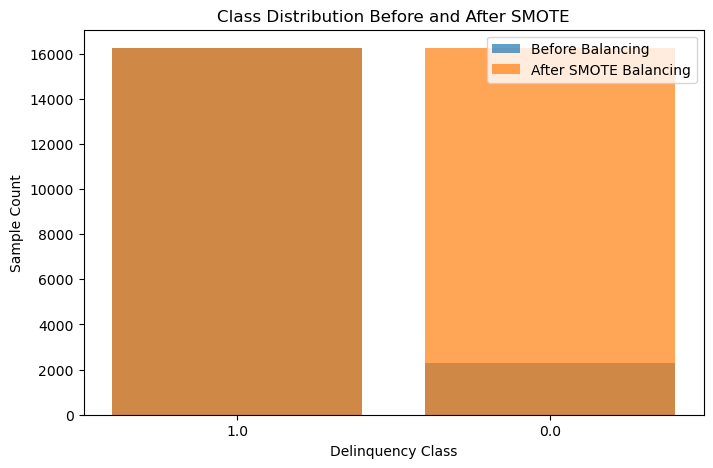

Fitting 3 folds for each of 256 candidates, totalling 768 fits


C:\Users\bog23\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:02:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_delta_step': 5, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
Best F1 Score: 0.895483344921027


C:\Users\bog23\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:02:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report of Optimized XGBoost:
              precision    recall  f1-score   support

         0.0       0.38      0.14      0.21       951
         1.0       0.89      0.97      0.93      6987

    accuracy                           0.87      7938
   macro avg       0.63      0.56      0.57      7938
weighted avg       0.83      0.87      0.84      7938



C:\Users\bog23\AppData\Local\Temp\ipykernel_12852\1404516446.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


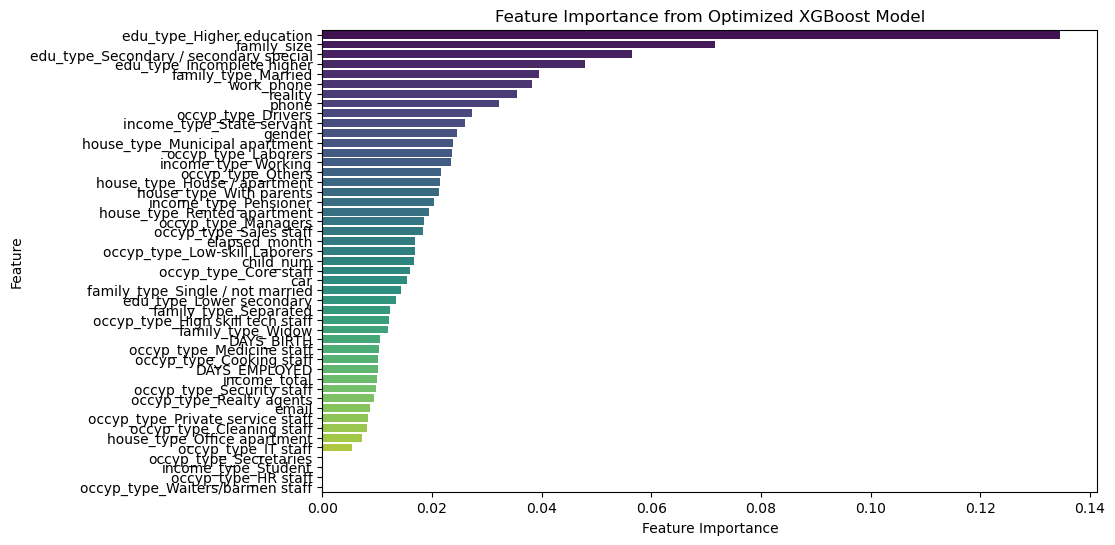

<Figure size 1000x600 with 0 Axes>

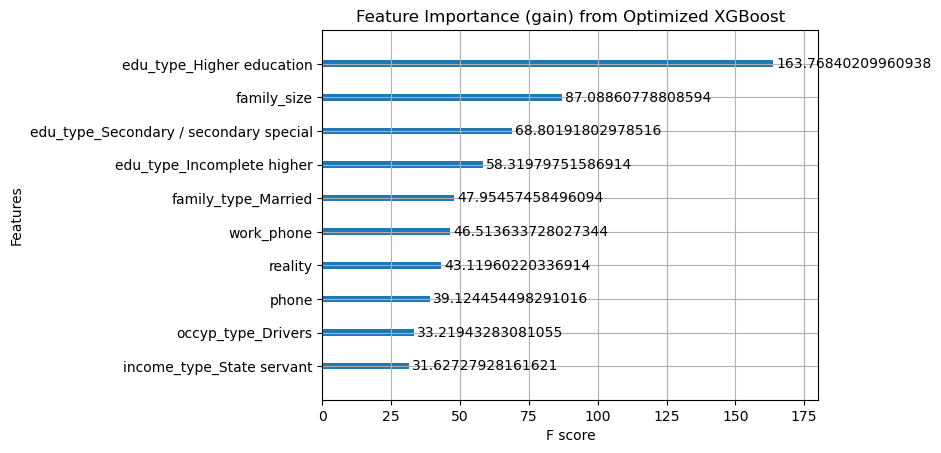

In [1]:
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv("data/processed_credit_data_5.csv")

# 피처와 타겟 변수 분리
X = df.drop(columns=['delinquency', 'index'])
y = df['delinquency']

# 클래스 레이블 재매핑: 0은 그대로 유지, 1과 2는 합쳐서 1로 설정
y = y.replace({1.0: 1, 2.0: 1})

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# SMOTE 적용
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# SMOTE 적용 전후의 클래스 분포 확인
before_counts = y_train.value_counts()
after_counts = pd.Series(y_train_smote).value_counts()

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(before_counts.index.astype(str), before_counts.values, alpha=0.7, label='Before Balancing')
plt.bar(after_counts.index.astype(str), after_counts.values, alpha=0.7, label='After SMOTE Balancing')
plt.xlabel('Delinquency Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution Before and After SMOTE')
plt.legend()
plt.show()

# X_test의 열을 학습 데이터와 동일하게 정렬
X_test = X_test[X_train_smote.columns]

# 하이퍼파라미터 그리드 간소화
param_grid = {
    'n_estimators': [100, 200],  # 적은 값으로 제한
    'learning_rate': [0.05, 0.1],  # 대표적인 두 값
    'max_depth': [3, 5],  # 최대 깊이 제한
    'min_child_weight': [1, 3],  # XGBoost에서 사용되는 값
    'subsample': [0.8, 1.0],  # 자주 사용되는 값만 선택
    'colsample_bytree': [0.8, 1.0],  # 자주 사용되는 값만 선택
    'gamma': [0, 0.1],  # XGBoost의 규제 파라미터
    'max_delta_step': [1, 5]  # 클래스 불균형 안정화 대체 옵션
}

# GridSearchCV 실행
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=0, objective='binary:logistic', use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='f1',  # F1 스코어를 기준으로 평가
    cv=3,          # 3-폴드 교차검증
    verbose=2,     # 진행 상황 출력
    n_jobs=-1      # 병렬 처리
)
grid_search.fit(X_train_smote, y_train_smote)

# 최적의 하이퍼파라미터 출력
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# 최적 파라미터로 모델 학습
best_model = grid_search.best_estimator_
best_model.fit(X_train_smote, y_train_smote)

# 테스트 데이터 예측
y_pred = best_model.predict(X_test)

# 모델 평가
print("Classification Report of Optimized XGBoost:")
print(classification_report(y_test, y_pred))

# 변수 중요도 추출 및 정리
feature_importances = best_model.feature_importances_
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Optimized XGBoost Model')
plt.show()

# XGBoost 내장 변수 중요도 플롯
plt.figure(figsize=(10, 6))
plot_importance(best_model, max_num_features=10, importance_type='gain')
plt.title("Feature Importance (gain) from Optimized XGBoost")
plt.show()


클래스 1 (Positive) Summary Plot:


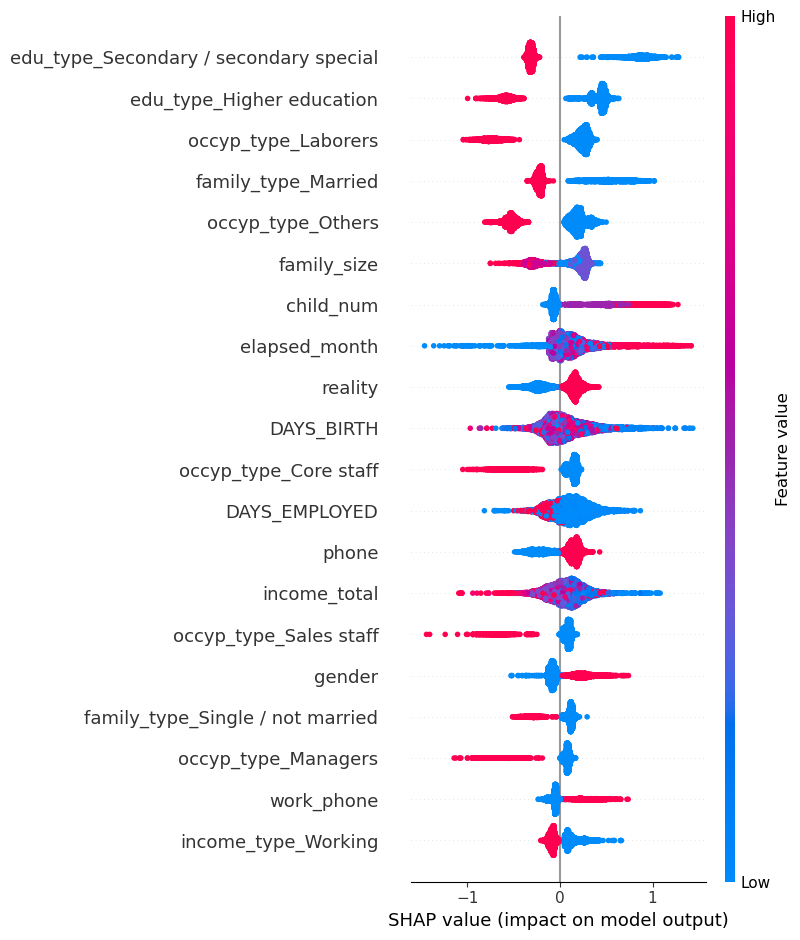

In [3]:
import shap

#SHAP Explainer 생성
explainer = shap.TreeExplainer(best_model)

#SHAP 값 계산
shap_values = explainer.shap_values(X_test)

# 클래스 1 (Positive) SHAP 값
shap_values_class_1 = shap_values

# 클래스 1 Summary Plot
print("\n클래스 1 (Positive) Summary Plot:")
shap.summary_plot(shap_values_class_1, X_test)